# Outlet Framing Analysis

Comparing frame usage between individual outlets and by political valence (Left, Center, Right).

In [2]:
%pip install pandas numpy matplotlib seaborn pyarrow scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

In [4]:
df = pd.read_parquet('merged_topic_and_frames_filtered_with_time_and_frames.parquet')
print(f'Loaded {len(df):,} articles')

frames = sorted(['economic', 'fairness', 'public_op', 'political', 'quality_life',
                 'crime', 'culture', 'health', 'legality', 'morality',
                 'policy', 'regulation', 'security', 'cap&res'])

frame_matrix = np.array(df['vector'].tolist())
for i, frame in enumerate(frames):
    df[f'frame_{frame}'] = frame_matrix[:, i]

frame_cols = [f'frame_{f}' for f in frames]

valence_map = {'Left': 'Left', 'Lean Left': 'Left', 'Center': 'Center', 'Lean Right': 'Right', 'Right': 'Right'}
df['valence'] = df['bias'].map(valence_map)

print(f'\nArticles by valence:')
print(df['valence'].value_counts())

Loaded 133,526 articles

Articles by valence:
valence
Left      72014
Right     41142
Center    20370
Name: count, dtype: int64


## Frame Usage by Individual Outlet

In [5]:
outlet_frames = df.groupby('outlet_name')[frame_cols].mean()
outlet_frames.columns = frames
outlet_frames['n_articles'] = df.groupby('outlet_name').size()
outlet_frames = outlet_frames.sort_values('n_articles', ascending=False)

outlet_frames.style.format('{:.1%}', subset=frames).format('{:,}', subset=['n_articles'])

,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security,n_articles
outlet_name,,,,,,,,,,,,,,,
Newsweek,4.0%,38.1%,21.1%,11.4%,37.7%,21.3%,68.2%,3.3%,59.5%,25.4%,31.7%,40.0%,22.2%,34.4%,"21,579"
Vox,8.5%,22.6%,27.2%,25.1%,41.5%,12.0%,56.3%,2.3%,75.9%,28.6%,37.9%,47.1%,15.9%,17.0%,"19,052"
Breitbart News,3.2%,45.6%,12.4%,9.6%,50.9%,11.5%,79.0%,6.1%,53.5%,37.8%,27.2%,17.3%,25.6%,37.1%,"14,671"
HuffPost,8.3%,22.6%,34.0%,16.9%,42.4%,25.1%,44.0%,4.8%,54.4%,19.0%,29.1%,59.1%,11.3%,14.7%,"9,617"
New York Post,5.0%,39.7%,20.5%,17.3%,32.2%,22.9%,60.5%,2.1%,47.8%,16.0%,23.6%,51.4%,9.3%,25.4%,"8,424"
CNBC,36.8%,7.9%,8.9%,71.5%,17.9%,14.6%,46.0%,0.3%,93.3%,9.0%,13.4%,55.9%,23.6%,21.6%,"7,957"
Vice,4.3%,30.2%,44.9%,14.4%,26.6%,16.2%,43.6%,1.8%,52.0%,10.9%,32.3%,64.8%,10.2%,23.5%,"7,580"
Reuters,31.9%,15.9%,4.7%,50.9%,18.6%,21.5%,64.8%,0.5%,86.2%,9.9%,8.2%,26.7%,43.7%,37.6%,"6,979"
Washington Times,4.1%,39.5%,11.9%,12.4%,43.1%,18.5%,80.3%,2.1%,62.6%,29.4%,21.8%,26.9%,19.3%,31.4%,"6,579"


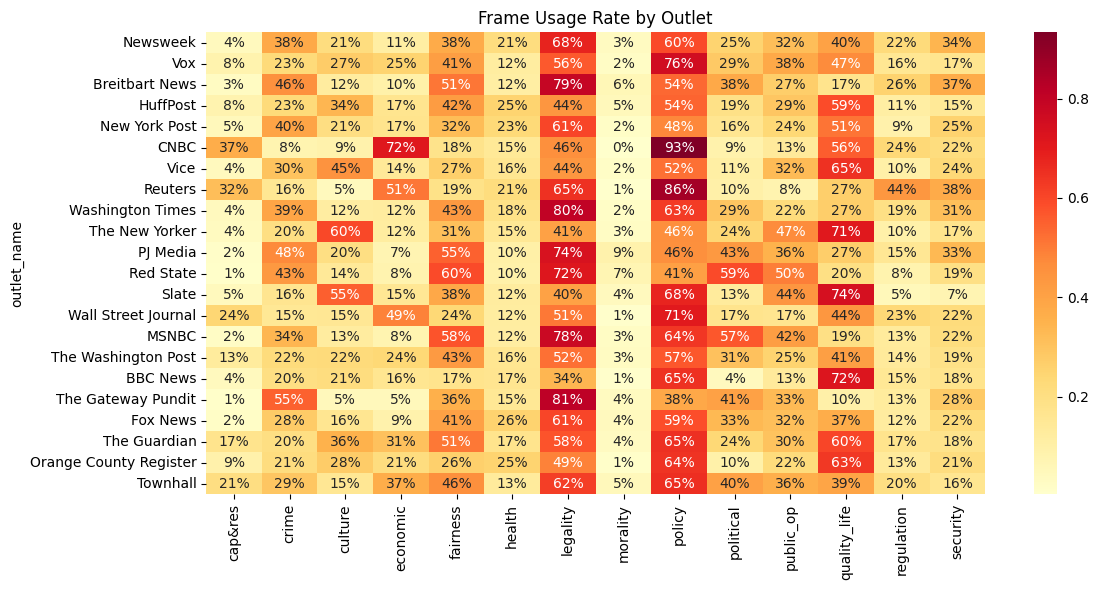

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(outlet_frames[frames], annot=True, fmt='.0%', cmap='YlOrRd', ax=ax)
plt.title('Frame Usage Rate by Outlet')
plt.tight_layout()
plt.show()

In [7]:
print('Frame usage range across outlets (max - min):\n')
for frame in frames:
    vals = outlet_frames[frame]
    print(f'{frame:15} {vals.min():.0%} - {vals.max():.0%}  (range: {vals.max()-vals.min():.0%})')

Frame usage range across outlets (max - min):

cap&res         1% - 37%  (range: 36%)
crime           8% - 55%  (range: 47%)
culture         5% - 60%  (range: 55%)
economic        5% - 72%  (range: 67%)
fairness        17% - 60%  (range: 42%)
health          10% - 26%  (range: 16%)
legality        34% - 81%  (range: 47%)
morality        0% - 9%  (range: 9%)
policy          38% - 93%  (range: 55%)
political       4% - 59%  (range: 55%)
public_op       8% - 50%  (range: 42%)
quality_life    10% - 74%  (range: 64%)
regulation      5% - 44%  (range: 38%)
security        7% - 38%  (range: 30%)


In [8]:
# Chi-square tests for outlet/frame associations
print('Statistical significance of outlet/frame associations:\n')
outlet_chi2_results = []
for frame in frames:
    col = f'frame_{frame}'
    contingency = pd.crosstab(df['outlet_name'], df[col])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    outlet_chi2_results.append({'frame': frame, 'chi2': chi2, 'p_value': p, 'significant': p < 0.05})

outlet_chi2_df = pd.DataFrame(outlet_chi2_results).sort_values('chi2', ascending=False)
outlet_chi2_df.style.format({'chi2': '{:.1f}', 'p_value': '{:.2e}'})

Statistical significance of outlet/frame associations:



,frame,chi2,p_value,significant
3,economic,22373.7,0.00e+00,True
0,cap&res,15934.1,0.00e+00,True
11,quality_life,14940.4,0.00e+00,True
2,culture,12614.7,0.00e+00,True
8,policy,10351.2,0.00e+00,True
9,political,10344.4,0.00e+00,True
6,legality,9794.8,0.00e+00,True
1,crime,8554.9,0.00e+00,True
4,fairness,6797.6,0.00e+00,True
12,regulation,6106.5,0.00e+00,True


## Frame Usage by Political Valence

In [9]:
valence_frames = df.groupby('valence')[frame_cols].mean()
valence_frames.columns = frames
valence_frames['n_articles'] = df.groupby('valence').size()
valence_frames = valence_frames.loc[['Left', 'Center', 'Right']]

valence_frames.style.format('{:.1%}', subset=frames).format('{:,}', subset=['n_articles'])

,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security,n_articles
valence,,,,,,,,,,,,,,,
Left,6.3%,28.0%,30.6%,16.9%,39.1%,17.4%,56.0%,3.1%,62.2%,24.7%,34.6%,49.9%,15.6%,22.4%,"72,014"
Center,29.6%,13.1%,9.8%,54.8%,19.0%,16.8%,51.9%,0.5%,84.2%,10.1%,12.1%,45.7%,29.5%,26.7%,"20,370"
Right,3.9%,42.0%,15.1%,12.1%,45.2%,15.7%,72.7%,4.6%,52.5%,33.4%,28.5%,29.0%,17.7%,30.3%,"41,142"


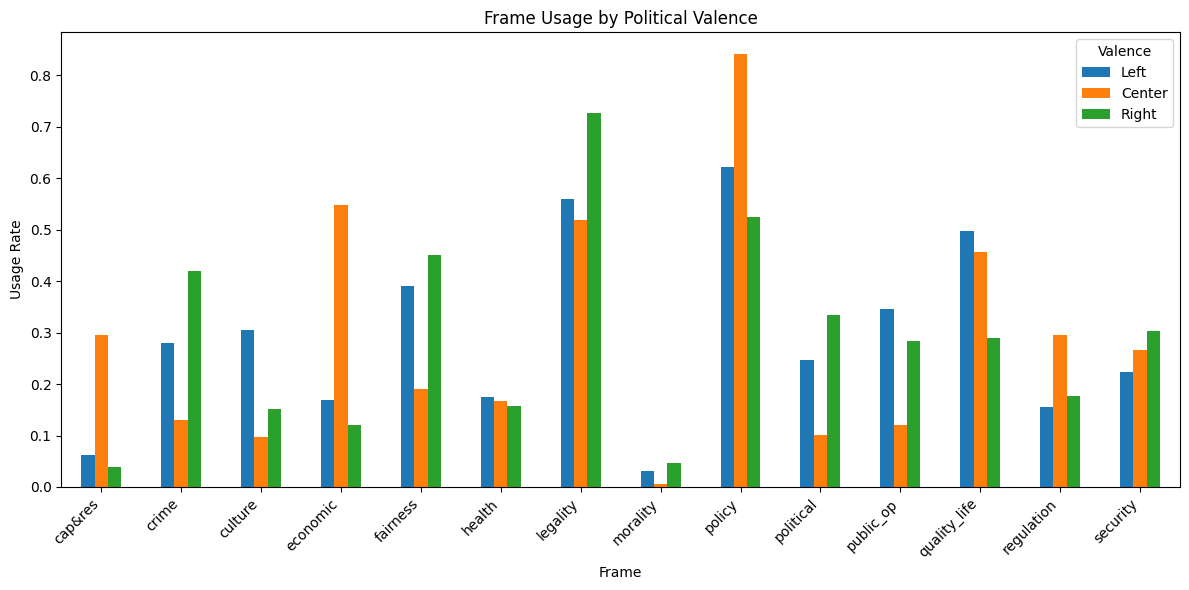

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
valence_frames[frames].T.plot(kind='bar', ax=ax)
plt.title('Frame Usage by Political Valence')
plt.xlabel('Frame')
plt.ylabel('Usage Rate')
plt.legend(title='Valence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# custom colormap to avoid red/blue political connotations
colors = ['#8B4513', '#FFFFFF', '#228B22']  # brown -> white -> green
cmap_neutral = LinearSegmentedColormap.from_list('BrownGreen', colors)

diff = valence_frames.loc['Left', frames] - valence_frames.loc['Right', frames]
diff_df = pd.DataFrame({'left_minus_right': diff}).sort_values('left_minus_right', key=abs, ascending=False)

print('Left vs Right frame usage difference:')
print('(positive/green = Left uses more, negative/brown = Right uses more)\n')
diff_df.style.format('{:+.1%}').background_gradient(cmap=cmap_neutral, vmin=-0.2, vmax=0.2)

Left vs Right frame usage difference:
(positive/green = Left uses more, negative/brown = Right uses more)



,left_minus_right
quality_life,+20.8%
legality,-16.6%
culture,+15.5%
crime,-14.0%
policy,+9.7%
political,-8.7%
security,-7.9%
public_op,+6.1%
fairness,-6.1%
economic,+4.8%


## Statistical Significance: Chi-Square Tests (Valence vs Frame)

In [12]:
chi2_results = []
for frame in frames:
    col = f'frame_{frame}'
    contingency = pd.crosstab(df['valence'], df[col])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi2_results.append({'frame': frame, 'chi2': chi2, 'p_value': p, 'significant': p < 0.05})

chi2_df = pd.DataFrame(chi2_results).sort_values('chi2', ascending=False)
chi2_df.style.format({'chi2': '{:.1f}', 'p_value': '{:.2e}'})

,frame,chi2,p_value,significant
3,economic,16583.4,0.00e+00,True
0,cap&res,12326.3,0.00e+00,True
8,policy,5862.6,0.00e+00,True
2,culture,5854.4,0.00e+00,True
1,crime,5729.0,0.00e+00,True
11,quality_life,4717.5,0.00e+00,True
4,fairness,4057.6,0.00e+00,True
9,political,3939.1,0.00e+00,True
10,public_op,3888.8,0.00e+00,True
6,legality,3777.3,0.00e+00,True


## Frame Usage by Valence and Topic

In [13]:
topics = df['topic_top1'].value_counts().index.tolist()
print('Topics:', topics)

Topics: ['elections and politics', 'entertainment', 'technology', 'crime', 'finance', 'pandemic', 'healthcare', 'Middle East', 'immigration', 'China', 'Russia']


In [14]:
# Claude Code used to enhance print table readability 
def valence_comparison_for_topic(topic):
    subset = df[df['topic_top1'] == topic]
    valence_topic = subset.groupby('valence')[frame_cols].mean()
    valence_topic.columns = frames
    valence_topic = valence_topic.loc[['Left', 'Center', 'Right']]
    diff = valence_topic.loc['Left'] - valence_topic.loc['Right']
    return valence_topic, diff

for topic in topics[:4]:
    valence_topic, diff = valence_comparison_for_topic(topic)
    n = len(df[df['topic_top1'] == topic])
    print(f'\n=== {topic.upper()} (n={n:,}) ===')
    print('\nFrame usage by valence:')
    display(valence_topic.style.format('{:.1%}'))
    print('\nLargest Left-Right differences:')
    top_diff = diff.abs().sort_values(ascending=False).head(5)
    for frame in top_diff.index:
        print(f'  {frame}: {diff[frame]:+.1%}')


=== ELECTIONS AND POLITICS (n=27,459) ===

Frame usage by valence:


,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,0.5%,28.0%,11.9%,7.4%,72.6%,4.4%,81.4%,3.4%,59.1%,77.3%,54.4%,10.7%,17.3%,15.3%
Center,4.2%,18.6%,5.0%,24.1%,55.1%,4.5%,83.2%,0.7%,70.5%,65.5%,32.7%,10.0%,35.2%,23.0%
Right,0.5%,30.7%,8.3%,6.5%,70.7%,3.6%,81.4%,4.6%,50.7%,78.0%,47.6%,8.8%,16.0%,14.6%



Largest Left-Right differences:
  policy: +8.4%
  public_op: +6.7%
  culture: +3.6%
  crime: -2.7%
  quality_life: +1.9%

=== ENTERTAINMENT (n=26,002) ===

Frame usage by valence:


,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,1.2%,13.9%,70.9%,8.0%,23.6%,10.7%,24.4%,3.8%,51.3%,10.3%,49.2%,84.3%,7.0%,6.7%
Center,5.3%,12.2%,46.5%,25.9%,14.6%,10.2%,22.4%,1.2%,62.1%,5.3%,29.0%,84.2%,17.9%,14.4%
Right,1.5%,22.7%,51.9%,8.7%,34.0%,13.0%,41.4%,8.1%,42.3%,24.3%,50.7%,67.6%,11.1%,11.1%



Largest Left-Right differences:
  culture: +19.0%
  legality: -17.0%
  quality_life: +16.7%
  political: -14.0%
  fairness: -10.3%

=== TECHNOLOGY (n=20,670) ===

Frame usage by valence:


,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,16.9%,14.8%,27.2%,38.2%,16.9%,17.7%,41.6%,1.1%,80.2%,5.9%,25.9%,66.3%,18.0%,24.3%
Center,34.1%,9.1%,12.2%,58.1%,9.6%,12.8%,42.2%,0.4%,90.9%,2.9%,11.3%,55.3%,35.9%,24.8%
Right,11.1%,27.5%,15.5%,22.1%,25.7%,21.0%,60.3%,2.4%,68.5%,15.2%,23.5%,44.0%,21.1%,33.7%



Largest Left-Right differences:
  quality_life: +22.2%
  legality: -18.7%
  economic: +16.1%
  crime: -12.6%
  culture: +11.7%

=== CRIME (n=18,802) ===

Frame usage by valence:


,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,0.4%,91.4%,14.1%,2.2%,43.3%,11.2%,85.5%,6.1%,44.0%,11.9%,16.9%,31.2%,9.6%,48.7%
Center,0.7%,87.1%,6.1%,6.1%,29.8%,7.4%,82.3%,2.6%,53.9%,9.3%,9.1%,22.8%,21.5%,48.5%
Right,0.2%,95.2%,6.2%,1.2%,34.1%,10.1%,85.8%,5.0%,31.2%,12.6%,10.4%,20.4%,7.5%,52.3%



Largest Left-Right differences:
  policy: +12.8%
  quality_life: +10.8%
  fairness: +9.2%
  culture: +7.9%
  public_op: +6.5%


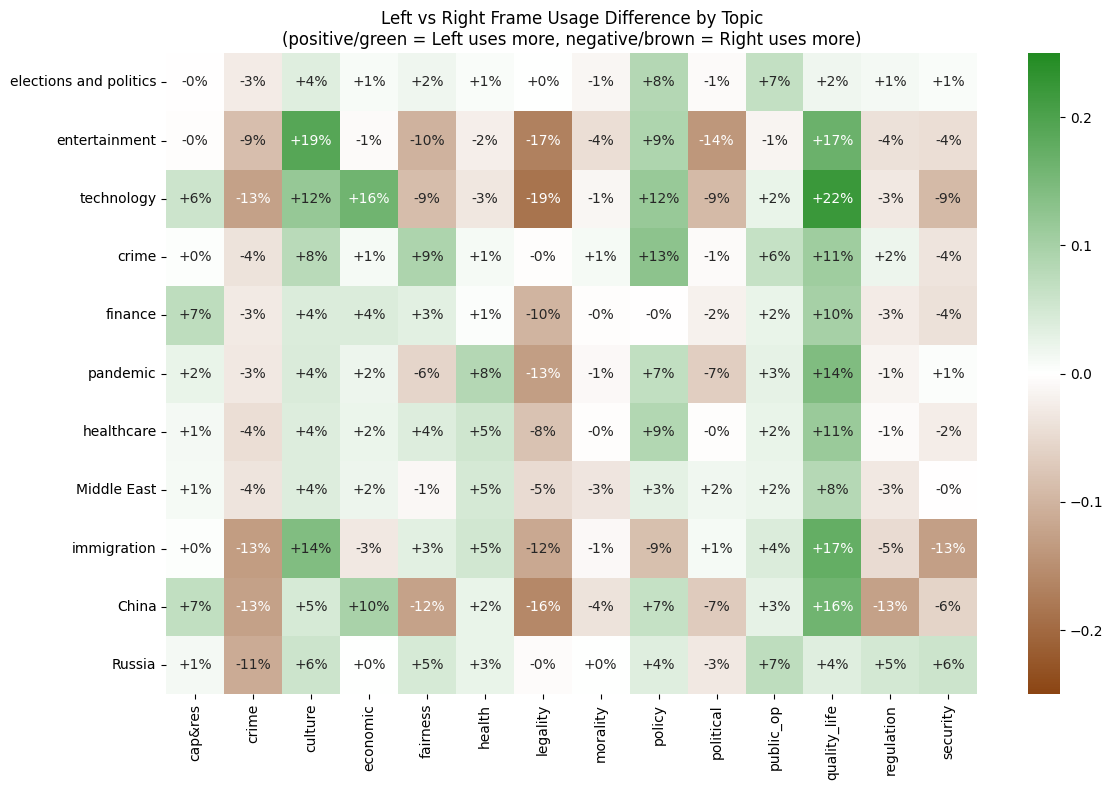

In [15]:
diff_by_topic = []
for topic in topics:
    _, diff = valence_comparison_for_topic(topic)
    diff_by_topic.append(diff)

diff_matrix = pd.DataFrame(diff_by_topic, index=topics)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(diff_matrix, annot=True, fmt='+.0%', cmap=cmap_neutral, center=0, ax=ax, vmin=-0.25, vmax=0.25)
plt.title('Left vs Right Frame Usage Difference by Topic\n(positive/green = Left uses more, negative/brown = Right uses more)')
plt.tight_layout()
plt.show()

## Frame Trends Over Time by Outlet

In [16]:
df['date'] = pd.to_datetime(df['date'])
df['quarter'] = df['date'].dt.to_period('Q')

outlet_trends = []
for outlet in df['outlet_name'].unique():
    subset = df[df['outlet_name'] == outlet]
    quarterly = subset.groupby('quarter')[frame_cols].mean()
    x = np.arange(len(quarterly))

    for frame_col in frame_cols:
        y = quarterly[frame_col].values
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        outlet_trends.append({'outlet': outlet, 'frame': frame_col.replace('frame_', ''), 'slope_per_year': slope * 4, 'p_value': p_value})

outlet_trend_df = pd.DataFrame(outlet_trends)
outlet_trend_pivot = outlet_trend_df.pivot(index='outlet', columns='frame', values='slope_per_year')
outlet_trend_pivot = outlet_trend_pivot[frames]
outlet_trend_pivot.style.format('{:+.1%}').background_gradient(cmap='PiYG', vmin=-0.05, vmax=0.05)

frame,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
outlet,,,,,,,,,,,,,,
BBC News,-0.7%,+2.1%,+3.7%,+1.1%,-1.4%,+0.4%,-3.5%,+0.2%,-2.7%,-0.4%,-2.0%,+3.5%,-1.4%,+2.7%
Breitbart News,+0.1%,-0.2%,-1.3%,-0.0%,-0.0%,+1.7%,+1.3%,-0.1%,+0.6%,-0.6%,-1.8%,-0.2%,+0.3%,+0.2%
CNBC,-0.2%,+0.1%,-0.5%,-1.8%,+0.3%,+2.2%,+1.1%,-0.0%,+0.6%,-0.4%,-0.6%,+1.1%,+0.8%,+0.0%
Fox News,-0.1%,-3.0%,-1.4%,-0.1%,+1.8%,+2.7%,+0.8%,-1.4%,+1.8%,+0.4%,+0.6%,+0.7%,-0.8%,-1.5%
HuffPost,-1.4%,+3.7%,-3.0%,-2.2%,+0.4%,-0.0%,+5.4%,-0.3%,-1.3%,+2.5%,+0.1%,-4.9%,+0.3%,+2.6%
MSNBC,+1.0%,-1.4%,+4.1%,+0.8%,+1.6%,+1.4%,-5.0%,-0.3%,+3.6%,-4.6%,-2.9%,+5.7%,-0.7%,-1.5%
New York Post,-0.0%,-0.6%,-1.4%,-1.1%,-0.8%,+2.8%,+0.3%,-0.0%,+1.4%,+0.2%,-0.7%,-1.2%,+0.5%,+1.3%
Newsweek,-0.1%,-0.6%,-0.5%,-0.9%,+0.5%,+2.5%,-0.7%,+0.0%,+0.3%,-0.2%,+0.6%,+1.5%,-2.7%,-2.0%
Orange County Register,+1.2%,-1.4%,-2.6%,+0.2%,-0.5%,+1.5%,+3.0%,+0.1%,+2.7%,-0.4%,-1.5%,-0.9%,+0.8%,-0.1%


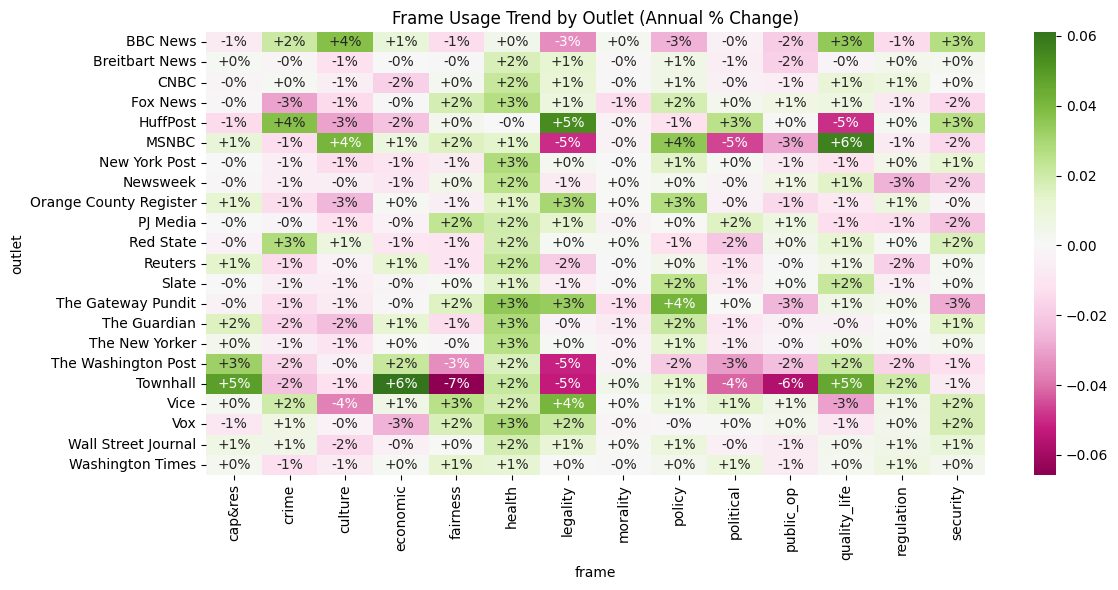

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(outlet_trend_pivot, annot=True, fmt='+.0%', cmap='PiYG', center=0, ax=ax)
plt.title('Frame Usage Trend by Outlet (Annual % Change)')
plt.tight_layout()
plt.show()

## Frame Trends Over Time by Political Valence

In [18]:
valence_trends = []
for valence in ['Left', 'Center', 'Right']:
    subset = df[df['valence'] == valence]
    quarterly = subset.groupby('quarter')[frame_cols].mean()
    x = np.arange(len(quarterly))

    for frame_col in frame_cols:
        y = quarterly[frame_col].values
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        valence_trends.append({'valence': valence, 'frame': frame_col.replace('frame_', ''), 'slope_per_year': slope * 4, 'p_value': p_value})

valence_trend_df = pd.DataFrame(valence_trends)
valence_trend_pivot = valence_trend_df.pivot(index='valence', columns='frame', values='slope_per_year')
valence_trend_pivot = valence_trend_pivot.loc[['Left', 'Center', 'Right'], frames]
valence_trend_pivot.style.format('{:+.1%}').background_gradient(cmap='PiYG', vmin=-0.03, vmax=0.03)

frame,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
valence,,,,,,,,,,,,,,
Left,-0.5%,+1.2%,-1.3%,-1.6%,+0.7%,+2.3%,+2.0%,-0.1%,-0.4%,+0.2%,+0.1%,-1.0%,-0.0%,+1.3%
Center,+1.9%,-0.5%,-0.6%,+2.1%,-0.4%,+2.1%,+0.3%,-0.0%,+1.7%,-0.6%,-0.8%,+0.1%,+0.5%,+1.1%
Right,+0.4%,-0.4%,-0.9%,+0.2%,-0.5%,+2.0%,+0.6%,-0.2%,+0.7%,-0.7%,-1.3%,+0.3%,+0.4%,+0.1%


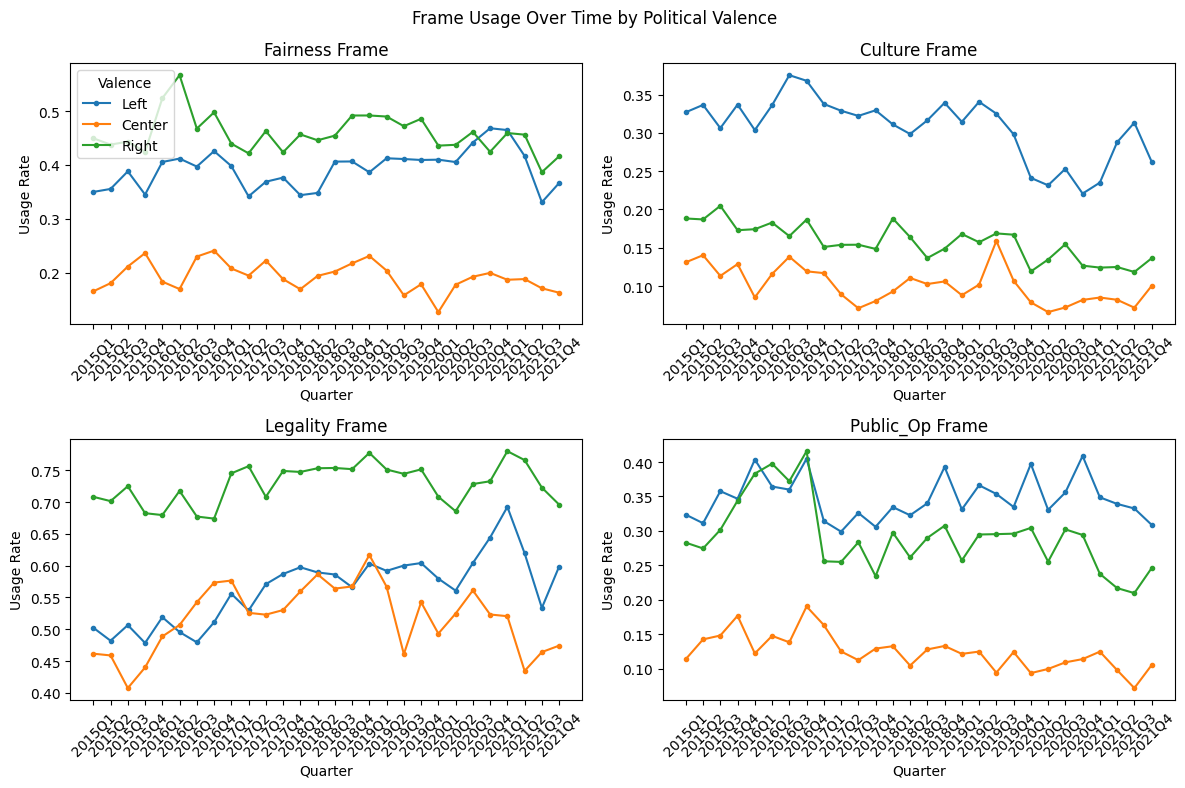

In [19]:
key_frames = ['fairness', 'culture', 'legality', 'public_op']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, frame in enumerate(key_frames):
    frame_col = f'frame_{frame}'
    ax = axes[idx]

    for valence in ['Left', 'Center', 'Right']:
        subset = df[df['valence'] == valence]
        quarterly = subset.groupby('quarter')[frame_col].mean()
        ax.plot(quarterly.index.astype(str), quarterly.values, label=valence, marker='o', markersize=3)

    ax.set_title(f'{frame.title()} Frame')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Usage Rate')
    ax.tick_params(axis='x', rotation=45)

axes[0].legend(title='Valence')
plt.suptitle('Frame Usage Over Time by Political Valence', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/qx/s3x88ny97x50pncly3d8f41c0000gn/T/ipykernel_73713/2148194899.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{t:.0f}%' for t in ax.get_yticks()])


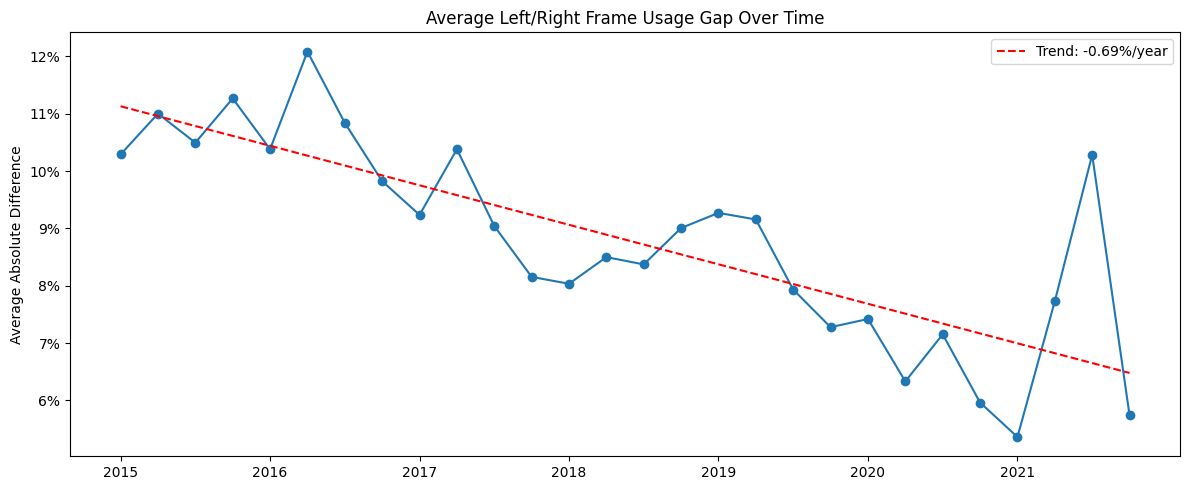

In [ ]:
# check if valences are converging or diverging

quarterly_gap = []
for quarter in sorted(df['quarter'].unique()):
    q_df = df[df['quarter'] == quarter]
    left_mean = q_df[q_df['valence'] == 'Left'][frame_cols].mean()
    right_mean = q_df[q_df['valence'] == 'Right'][frame_cols].mean()
    gap = (left_mean - right_mean).abs().mean()
    quarterly_gap.append({'quarter': quarter, 'avg_gap': gap})

gap_df = pd.DataFrame(quarterly_gap).sort_values('quarter')
x = np.arange(len(gap_df))
y = gap_df['avg_gap'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Get year ticks instead of quarter labels
all_quarters_str = [str(q) for q in gap_df['quarter']]
year_tick_indices = [i for i, q in enumerate(all_quarters_str) if q.endswith('Q1')]
year_labels = [q[:4] for q in all_quarters_str if q.endswith('Q1')]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, gap_df['avg_gap'] * 100, marker='o')
ax.plot(x, (intercept + slope * x) * 100, 'r--', label=f'Trend: {slope*4:+.2%}/year')

plt.title('Average Left/Right Frame Usage Gap Over Time')
plt.ylabel('Average Absolute Difference')
ax.set_xticks(year_tick_indices)
ax.set_xticklabels(year_labels)
ax.set_yticklabels([f'{t:.0f}%' for t in ax.get_yticks()])
plt.legend()
plt.tight_layout()
plt.show()

print(f'Gap trend: {slope*4:+.2%} per year (p={p_value:.4f})')
if slope > 0:
    print('Left and Right outlets are diverging in their framing over time')
else:
    print('Left and Right outlets are converging in their framing over time')